In [9]:
import os, json, time, re, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv

# ✅ Load environment variables اول از همه
load_dotenv()

# ✅ Import RAG system
sys.path.insert(0, r"F:\Thesis\project\2-RAG\vector_store")
from legal_rag_retrieval import legal_rag_retrieve, format_results_for_llm
print("✅ RAG system loaded")

# ✅ Setup OpenRouter API
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)
print("✅ OpenRouter client ready")

# ✅ Load questions
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions.csv")
print(f"📊 Loaded {len(df)} questions")

# ✅ Load Gold answers + Fix باگ‌ها
gold_df = pd.read_csv(r"F:\Thesis\project\1-BaselineTest\GOLD\Gold.csv")

# Fix سوال 52: "2-Apr" → "2-4"
if 52 in gold_df['idx'].values:
    gold_df.loc[gold_df['idx'] == 52, 'Gold'] = "2-4"
    print("✅ Fixed question 52: 2-Apr → 2-4")

# حذف سوال 89 (Gold=0)
if 89 in gold_df['idx'].values:
    gold_df = gold_df[gold_df['idx'] != 89].reset_index(drop=True)
    print("✅ Removed question 89")

print(f"✅ {len(gold_df)} gold answers ready")

✅ RAG system loaded
✅ OpenRouter client ready
📊 Loaded 120 questions
✅ Fixed question 52: 2-Apr → 2-4
✅ 119 gold answers ready


In [10]:
def to_list(opts):
    """تبدیل options از هر فرمت به list"""
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

def render_numeric_options(opts):
    """نمایش گزینه‌ها به فرمت عددی 1) 2) 3) 4)"""
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [11]:
def build_messages_with_rag(question: str, options_text: str, rag_context: str):
    """
    Few-Shot CoT e2p + RAG context با خروجی TOON (به‌جای JSON)
    """
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal Question Answering System (TOON + RAG)\n"
                "You are a **professional legal reasoning assistant** specialized in **Iranian law**.\n"
                "---\n"
                "## Task:\n"
                "- Language: Persian (فارسی)\n"
                "- Objective: Analyze the question based on Iranian law and choose the **correct option number (1–4)**.\n"
                "- Provide a **short legal explanation (1–2 sentences in Persian)** describing:\n"
                "  1. Which legal article, principle, or rule applies.\n"
                "  2. Why that rule leads to the chosen answer.\n"
                "- Only explain **why the correct option is right** — do not analyze incorrect options.\n"
                "- After the explanation, output the final result in **valid TOON format**.\n"
                "---\n"
                "## Confidence Scale (5 Levels):\n"
                "- 1: UNCERTAIN — Cannot distinguish between two or more options.\n"
                "- 2: WEAK — Significant doubt or debatable interpretation.\n"
                "- 3: MODERATE — Fairly confident; based on a standard or commonly accepted interpretation.\n"
                "- 4: STRONG — Confident; clear legal article, rule, or precedent supports the choice.\n"
                "- 5: VERY STRONG — Certain; unambiguous and directly supported by law.\n"
                "---\n"
                "# ------------------ FEW-SHOT EXAMPLES (TOON) ------------------\n"
                "\n# Example 1 (confidence=5)\n"
                "User: سؤال: کدام‌يک از مراجع ذکر شده در قانون اساسی، مرجع تخصصی قضايی محسوب می‌شود؟\n"
                "گزینه‌ها:\n"
                "1) دادستانی کل کشور\n"
                "2) دیوان محاسبات کشور\n"
                "3) دیوان عدالت اداری\n"
                "4) دیوان عالی کشور\n"
                "Assistant (TOON):\n"
                "results{explanation,answer,confidence}:\n"
                "براساس اصل 173 قانون اساسی، دیوان عدالت اداری مرجع تخصصی قضایی برای رسیدگی به شکایات مردم علیه مأمورین و آیین‌نامه‌های دولتی است.,3,5\n"
                "\n# Example 2 (confidence=4)\n"
                "User: سؤال: آیا وجود قرابت نسبی یا سببی بین وکلای طرفین دعوا در یک پرونده جریانی، موجب ممنوعیت از انجام وکالت در پرونده است؟\n"
                "گزینه‌ها:\n"
                "1) در صورت تسخیری بودن وکالت یکی از وکلا، قرابت تا درجه سوم از هر طبقه موجب ممنوعیت وکیل تسخیری از انجام وکالت در پرونده است.\n"
                "2) قرابت تا درجه سوم از هر طبقه بین وکلای تعیینى طرفین دعوا، موجب ممنوعیت از انجام وکالت در پرونده است.\n"
                "3) مطلقاً از موجبات ممنوعیت از انجام وکالت در پرونده است.\n"
                "4) از موجبات ممنوعیت از انجام وکالت در پرونده نیست.\n"
                "Assistant (TOON):\n"
                "results{explanation,answer,confidence}:\n"
                "مطابق ماده 349 قانون آیین دادرسی کیفری، قرابت تا درجه سوم فقط در صورت تسخیری بودن وکالت موجب ممنوعیت است.,1,4\n"
                "\n# Example 3 (confidence=3)\n"
                "User: سؤال: «الف» مبادرت به جعل چک تضمین‌شده می‌نماید و آن را به «ب» می‌دهد. «ب» پس از ارائه چک به بانک، متوجه جعلی بودن می‌شود. «الف» چه جرمی را مرتکب شده است؟\n"
                "گزینه‌ها:\n"
                "1) جعل و استفاده از سند مجعول و صدور چک بلامحل\n"
                "2) جعل و معاونت در استفاده از سند مجعول\n"
                "3) جعل و استفاده از سند مجعول\n"
                "4) جعل و صدور چک بلامحل\n"
                "Assistant (TOON):\n"
                "results{explanation,answer,confidence}:\n"
                "چون صدور چک بلامحل فقط در صورت صادرکننده واقعی صادقه است و استفاده نیز توسط جاعل انجام شده، جرم جعل و استفاده از سند مجعول تحقق دارد.,3,3\n"
                "\n# Example 4 (confidence=2)\n"
                "User: سؤال: اگر شخصی مالی را که در ید امانت است بفروشد ولی آن را تحویل ندهد، آیا مرتکب خیانت در امانت شده است؟\n"
                "گزینه‌ها:\n"
                "1) بله، صرف اقدام به فروش کافی است.\n"
                "2) خیر، تا زمانی که مال تسلیم نشود، جرم تحقق نمی‌یابد.\n"
                "3) بستگی به قصد مرتکب دارد.\n"
                "4) در هر حال خیانت در امانت محسوب می‌شود.\n"
                "Assistant (TOON):\n"
                "results{explanation,answer,confidence}:\n"
                "صرف فروش مال امانی بدون تصرف مادی هنوز موجب استیلای غیرقانونی نیست؛ تحقق جرم نیازمند تسلیم یا تصرف است.,2,2\n"
                "\n# Example 5 (confidence=1)\n"
                "User: سؤال: اگر دو شاهد در شهادت خود دچار تردید شوند ولی هر دو اصل وقوع جرم را تأیید کنند، آیا شهادت آنان معتبر است؟\n"
                "گزینه‌ها:\n"
                "1) معتبر است، چون اصل وقوع جرم را تأیید کرده‌اند.\n"
                "2) معتبر نیست، چون یقین و جزم در شهادت شرط است.\n"
                "3) فقط در امور مدنی معتبر است.\n"
                "4) بستگی به نوع جرم دارد.\n"
                "Assistant (TOON):\n"
                "results{explanation,answer,confidence}:\n"
                "مطابق ماده 1315 قانون مدنی، شهادت باید با جزم باشد؛ تردید موجب سقوط اعتبار است، هرچند در عمل اختلاف نظر وجود دارد.,2,1\n"
                "---\n"
                "## OUTPUT FORMAT (TOON):\n"
                "Return **exactly one TOON table** with one row, like this:\n"
                "results{explanation,answer,confidence}:\n"
                "توضیح کوتاه حقوقی شامل ماده یا قاعده و استدلال,X,Y\n"
                "- explanation → short legal reasoning (in Persian, 1–2 sentences)\n"
                "- answer → one of 1,2,3,4\n"
                "- confidence → integer 1–5 according to the defined scale\n"
                "---\n"
                "⚠️ IMPORTANT:\n"
                "- Do NOT add extra text before or after the TOON table.\n"
                "- The first line must be: results{explanation,answer,confidence}:\n"
                "- The second line must contain exactly one row: explanation,answer,confidence"
            )
        },
        {
            "role": "user",
            "content": f"""📚 قوانین و آراء مرتبط (فقط از این‌ها استفاده کن):

{rag_context}

---

Question:
{question}

Options:
{options_text}

Expected output format (TOON):
results{{explanation,answer,confidence}}:
توضیح کوتاه حقوقی شامل ماده یا قاعده و استدلال,شماره_گزینه,میزان_اطمینان"""
        }
    ]

In [12]:
def extract_toon(content: str, verbose: bool = False):
    """
    Extract a single-row TOON table from an LLM response.

    Expected pattern (any surrounding text will be ignored):

        results{explanation,answer,confidence}:
        توضیح...,2,4

    Returns:
        dict | None:
            {
                "explanation": str,
                "answer": str,
                "confidence": int | None
            }
    """
    import re

    if not content or not str(content).strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None

    content = str(content).strip()

    # Remove markdown code fences ``````
    if content.startswith("```"):
        lines = content.split("\n")
        if lines and lines.strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        content = "\n".join(lines).strip()

    # Normalize newlines (robust against extra text)
    lines = [ln.rstrip() for ln in content.splitlines() if ln.strip()]
    if verbose:
        preview = "\n".join(lines[:5])
        print(f"🔎 TOON lines preview:\n{preview}")

    # 1) پیدا کردن خط هدر TOON
    header_idx = None
    header_match = None
    header_pattern = re.compile(
        r'^results\[\d*\]\s*\{\s*explanation\s*,\s*answer\s*,\s*confidence\s*\}\s*:$',
        re.IGNORECASE
    )
    simple_header_pattern = re.compile(
        r'^results\s*\{\s*explanation\s*,\s*answer\s*,\s*confidence\s*\}\s*:$',
        re.IGNORECASE
    )

    for i, ln in enumerate(lines):
        if header_pattern.match(ln) or simple_header_pattern.match(ln):
            header_idx = i
            header_match = ln
            break

    if header_idx is None:
        if verbose:
            print("⚠️ No TOON header 'results{explanation,answer,confidence}:' found")
        return None

    if verbose:
        print(f"✓ Found TOON header at line {header_idx}: {header_match!r}")

    # 2) ردیف بعد از هدر را به‌عنوان تنها ردیف داده می‌گیریم
    if header_idx + 1 >= len(lines):
        if verbose:
            print("⚠️ No data row found after TOON header")
        return None

    data_line = lines[header_idx + 1].strip()
    if verbose:
        print(f"🔎 TOON data row: {data_line!r}")

    # 3) Split CSV-style: explanation,answer,confidence
    # توجه: توضیح ممکن است شامل کاما باشد؛ بنابراین فقط اولین دو کاما را جدا می‌کنیم
    parts = [p.strip() for p in data_line.split(",", 2)]
    if len(parts) != 3:
        if verbose:
            print(f"⚠️ Expected 3 fields (explanation, answer, confidence), got {len(parts)}: {parts}")
        return None

    explanation_raw, answer_raw, conf_raw = parts

    # 4) پاک‌سازی توضیح (حذف کوتیشن‌های اضافی در صورت وجود)
    explanation = explanation_raw.strip().strip('"').strip("'")

    # 5) نرمال‌سازی answer (باید یکی از 1–4 باشد، به صورت string)
    answer = answer_raw.strip().strip('"').strip("'")
    # فقط رقم آخر را اگر 1-4 بود نگه می‌داریم
    m_ans = re.search(r'([1-4])$', answer)
    answer_norm = m_ans.group(1) if m_ans else None

    # 6) نرمال‌سازی confidence به int
    conf_norm = None
    conf_raw_clean = conf_raw.strip().strip('"').strip("'")
    if conf_raw_clean:
        try:
            conf_norm = int(float(conf_raw_clean))
        except Exception:
            if verbose:
                print(f"⚠️ Could not parse confidence value: {conf_raw_clean!r}")
            conf_norm = None

    result = {
        "explanation": explanation,
        "answer": answer_norm,
        "confidence": conf_norm
    }

    if verbose:
        print(f"✓ Parsed TOON → {result}")

    # اگر answer خالی بود، کل result را نامعتبر در نظر بگیر
    if result["answer"] is None:
        if verbose:
            print("⚠️ Parsed TOON has no valid answer (1–4)")
        return None

    return result

In [13]:
VALID_CONFIDENCE = {1, 2, 3, 4, 5}

def call_model(
    client,
    model: str, 
    messages, 
    temperature: float = 0.1, 
    max_tokens: int = 4096,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 60.0,
    stop: list | None = None,
):
    """
    Stable call: extracts explanation, answer, confidence, and token usage.
    حالا بر اساس خروجی TOON (نه JSON).
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    t0 = time.time()
    content = None

    try:
        # --- Model Call ---
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=timeout,
            stop=stop,
        )

        latency = int((time.time() - t0) * 1000)

        # --- Extract content safely (Claude-friendly) ---
        choice0 = resp.choices[0]
        msg = getattr(choice0, "message", None)
        content = None

        if msg is not None:
            msg_content = getattr(msg, "content", None)
            if isinstance(msg_content, list):
                # Anthropic-style: list of content blocks
                parts = []
                for block in msg_content:
                    text_part = getattr(block, "text", None)
                    if text_part:
                        parts.append(text_part)
                content = "\n".join(parts) if parts else None
            else:
                content = msg_content
        else:
            content = getattr(choice0, "text", None)

        if not content or not str(content).strip():
            raise ValueError("Model returned no text content")

        content = str(content).strip()

        # --- Usage tokens (may be None if provider doesn't return) ---
        usage = getattr(resp, "usage", None)
        prompt_tokens     = getattr(usage, "prompt_tokens", None) if usage else None
        completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
        total_tokens      = getattr(usage, "total_tokens", None) if usage else None

        if verbose:
            finish_reason = getattr(choice0, "finish_reason", None)
            print(f"\n🔍 Model: {model} | Latency: {latency} ms | finish_reason: {finish_reason} | usage: {getattr(usage, '__dict__', usage)}")
            print(f"🔍 Raw output preview:\n{content[:200]}...\n")

        # --- Extract TOON structure (explanation/answer/confidence) ---
        data = extract_toon(content, verbose=verbose)
        if not data:
            raise ValueError("Failed to extract valid TOON structure from model output")

        # --- Parse fields ---
        explanation = str(data.get("explanation", "") or "").strip()
        explain_len_chars = len(explanation) if explanation else 0
        explain_len_words = len(explanation.split()) if explanation else 0

        answer = str(data.get("answer", "")).strip().strip('"').strip("'")
        if answer not in valid_answers:
            raise ValueError(f"Invalid answer '{answer}', expected one of {valid_answers}")

        conf_raw = data.get("confidence", None)
        if conf_raw is None:
            raise ValueError("Missing 'confidence' field in model output")

        try:
            confidence = int(conf_raw)
        except Exception:
            try:
                confidence = int(float(str(conf_raw).strip()))
            except Exception:
                raise ValueError(f"Invalid confidence value: {conf_raw}")

        if confidence not in VALID_CONFIDENCE:
            original = confidence
            confidence = min(VALID_CONFIDENCE, key=lambda x: abs(x - original))
            if verbose:
                print(f"⚠️ Adjusted confidence from {original} → {confidence}")

        if verbose:
            print(f"✅ Parsed (TOON) → answer={answer}, confidence={confidence}, explain_len(chars)={explain_len_chars}, tokens: p={prompt_tokens}, c={completion_tokens}, t={total_tokens}")

        return {
            "answer": answer,
            "confidence": confidence,
            "explanation": explanation,
            "raw": content,
            "latency_ms": latency,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "explain_len_chars": explain_len_chars,
            "explain_len_words": explain_len_words,
            "error": None,
        }

    except Exception as e:
        latency = int((time.time() - t0) * 1000)
        if verbose:
            print(f"❌ Error: {str(e)}")
            if content:
                print(f"❌ Raw content preview:\n{str(content)[:300]}...\n")

        return {
            "answer": None,
            "confidence": None,
            "explanation": "",
            "raw": content or "",
            "latency_ms": latency,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": str(e),
        }

In [14]:
def run_few_shot_e2p_rag(
    client,
    model: str,
    df,
    limit=None,
    rag_top_k: int = 3,
    verbose: bool = False
):
    """
    Run few-shot evaluation با RAG (فقط برای مقایسه با baseline بدون RAG).
    
    Returns:
        pd.DataFrame with columns:
        - id, model, rag_top_k, answer, confidence, explanation, latency_ms,
          prompt_tokens, completion_tokens, total_tokens,
          explain_len_chars, explain_len_words, raw, error
    """
    rows = []
    errors = []

    iterator = tqdm(df.iterrows(), total=len(df), desc=f"RAG-FewShot({model})", disable=verbose)

    processed = 0
    for idx, row in iterator:
        if limit is not None and processed >= int(limit):
            break

        qid = row.get("question_number", idx)

        try:
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)
            
            # ✅ RAG: بازیابی context مرتبط
            query_full = f"{q}\n\n{options_text}"
            rag_results = legal_rag_retrieve(
                query_full, 
                top_k=rag_top_k, 
                use_rerank=True, 
                verbose=False
            )
            rag_context = format_results_for_llm(rag_results)
            
            if verbose:
                print(f"\n📝 Q{qid}: {str(q)[:60]}...")
                print(f"📚 RAG → {rag_results[0]['metadata'].get('law_name', 'نامشخص')}")

            # ساخت messages با RAG context
            messages = build_messages_with_rag(q, options_text, rag_context)

            # Model call با فضای بیشتر (RAG context طولانی‌تره)
            result = call_model(
                client=client,
                model=model,
                messages=messages,
                temperature=0.1,
                max_tokens=4096,          # ✅ بیشتر برای RAG + CoT
                timeout=90.0,             # ✅ بیشتر برای RAG processing
                verbose=verbose
            )

            rec = {
                "id": qid,
                "model": model,
                "rag_top_k": rag_top_k,   # ✅ برای tracking
                "answer": result.get("answer"),
                "confidence": result.get("confidence"),
                "explanation": result.get("explanation", ""),
                "latency_ms": result.get("latency_ms"),
                "prompt_tokens": result.get("prompt_tokens"),
                "completion_tokens": result.get("completion_tokens"),
                "total_tokens": result.get("total_tokens"),
                "explain_len_chars": result.get("explain_len_chars"),
                "explain_len_words": result.get("explain_len_words"),
                "raw": result.get("raw", ""),
                "error": result.get("error"),
            }
            rows.append(rec)
            time.sleep(6)
            processed += 1

        except Exception as e:
            if verbose:
                print(f"❌ Q{qid}: {str(e)}")
            errors.append({"id": qid, "error": str(e)})

            rows.append({
                "id": qid,
                "model": model,
                "rag_top_k": rag_top_k,
                "answer": None,
                "confidence": None,
                "explanation": "",
                "latency_ms": None,
                "prompt_tokens": None,
                "completion_tokens": None,
                "total_tokens": None,
                "explain_len_chars": None,
                "explain_len_words": None,
                "raw": "",
                "error": str(e)
            })
            processed += 1
            continue

    if errors and verbose:
        print(f"\n⚠️ {len(errors)} questions had errors")

    df_out = pd.DataFrame(rows)
    desired_cols = [
        "id","model","rag_top_k","answer","confidence","explanation","latency_ms",
        "prompt_tokens","completion_tokens","total_tokens",
        "explain_len_chars","explain_len_words",
        "raw","error"
    ]
    df_out = df_out[[c for c in desired_cols if c in df_out.columns]]

    return df_out

In [15]:
# ================== شروع اجرا RAG ==================
print("="*70)
print("🚀 Few-Shot CoT + RAG Evaluation")
print("="*70)
print(f"📂 Dataset size: {len(df)} questions")
print(f"📊 Model: OpenAI: gpt-oss-120b")
print(f"📚 RAG top_k: 5")
print("="*70 + "\n")

start_time = time.time()

try:
    # ✅ RAG execution
    results = run_few_shot_e2p_rag(
        client=client,
        model="openai/gpt-oss-120b",
        df=df,
        rag_top_k=5,              # ✅ RAG parameter
        limit=None,               # None = همه
        verbose=True              # True برای دیدن RAG context
    )

    elapsed = time.time() - start_time

    # ================== خلاصه نتایج RAG ==================
    print("\n" + "="*70)
    print("✅ RAG Execution Completed!")
    print("="*70)
    print(f"📊 Processed: {len(results)} questions")
    print(f"⏱️  Total time: {elapsed/60:.1f} minutes ({elapsed:.1f} seconds)")
    print(f"⚡ Avg time per question: {elapsed/len(results):.2f} seconds")

    # ================== آمار کلیدی RAG ==================
    print("\n" + "="*70)
    print("📈 RAG Summary Statistics")
    print("="*70)

    # Confidence آمار
    if "confidence" in results.columns:
        valid_conf = results["confidence"].dropna()
        if len(valid_conf) > 0:
            avg_conf = valid_conf.mean()
            print(f"   Average confidence: {avg_conf:.1f}")
            print(f"   Median confidence: {valid_conf.median():.1f}")
            print(f"   Min confidence: {valid_conf.min():.1f}")
            print(f"   Max confidence: {valid_conf.max():.1f}")

            total = len(results)
            very_low = (valid_conf <= 2).sum()
            low      = ((valid_conf > 2) & (valid_conf <= 3)).sum()
            medium   = ((valid_conf > 3) & (valid_conf <= 4)).sum()
            high     = (valid_conf > 4).sum()

            print(f"\n   Very Low (≤2): {very_low} ({very_low/total*100:.1f}%)")
            print(f"   Low (2-3): {low} ({low/total*100:.1f}%)")
            print(f"   Medium (3-4): {medium} ({medium/total*100:.1f}%)")
            print(f"   High (>4): {high} ({high/total*100:.1f}%)")

    # ✅ RAG-specific آمار
    print(f"\n   📚 RAG top_k used: {results['rag_top_k'].iloc[0] if len(results) > 0 else 'N/A'}")

    # توزیع پاسخ‌ها
    if "answer" in results.columns:
        print(f"\n   Answer distribution:")
        answer_dist = results["answer"].value_counts().sort_index()
        for ans, count in answer_dist.items():
            print(f"      {ans}: {count} ({count/len(results)*100:.1f}%)")

    # خطاها
    if "error" in results.columns:
        errors_count = (results["error"].notna()).sum()
        if errors_count > 0:
            print(f"\n   ⚠️  Questions with errors: {errors_count} ({errors_count/len(results)*100:.1f}%)")
        else:
            print(f"\n   ✅ No errors!")

    # Latency آمار
    if "latency_ms" in results.columns:
        valid_latency = results["latency_ms"].dropna()
        if len(valid_latency) > 0:
            print(f"\n   Average latency: {valid_latency.mean():.0f}ms")
            print(f"   Median latency:  {valid_latency.median():.0f}ms")
            print(f"   Max latency:     {valid_latency.max():.0f}ms")

    # ================== آمار مبتنی بر توکن‌ها RAG ==================
    print("\n" + "="*70)
    print("🔎 RAG Token Analysis")
    print("="*70)

    have_tokens = {"prompt_tokens","completion_tokens","total_tokens"}.issubset(results.columns)
    if have_tokens:
        # خلاصه
        for col in ["prompt_tokens","completion_tokens","total_tokens"]:
            s = results[col].dropna()
            if len(s) > 0:
                print(f"   {col}: mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}")

        # همبستگی با confidence
        if "confidence" in results.columns:
            subset = results.dropna(subset=["confidence","completion_tokens"])
            if len(subset) > 1:
                corr_p = subset[["completion_tokens","confidence"]].corr(method="pearson").iloc[0,1]
                corr_s = subset[["completion_tokens","confidence"]].corr(method="spearman").iloc[0,1]
                print(f"\n   Correlation completion_tokens ~ confidence: Pearson={corr_p:.3f}, Spearman={corr_s:.3f}")

        # طول explain و اعتماد
        if {"explain_len_words","confidence"}.issubset(results.columns):
            sub = results.dropna(subset=["explain_len_words","confidence"])
            if len(sub) > 1:
                corr_ep = sub[["explain_len_words","confidence"]].corr(method="pearson").iloc[0,1]
                corr_es = sub[["explain_len_words","confidence"]].corr(method="spearman").iloc[0,1]
                print(f"   Correlation explain_len_words ~ confidence: Pearson={corr_ep:.3f}, Spearman={corr_es:.3f}")
    else:
        print("   ⚠️ Token usage columns not found")

    # ================== ذخیره نتایج RAG ==================
    print("\n" + "="*70)
    print("💾 Saving RAG Results")
    print("="*70)

    # CSV
    csv_filename = f"results_few_shot_RAG_gpt-oss-120_topk5.csv"
    results.to_csv(csv_filename, index=False, encoding="utf-8-sig")
    print(f"   ✅ CSV saved: {csv_filename}")

    # ================== نمایش نمونه RAG ==================
    print("\n" + "="*70)
    print("📋 Sample RAG Results (First 10)")
    print("="*70)
    display_cols = [c for c in [
        "id","model","rag_top_k","answer","confidence","explanation","latency_ms","error",
        "completion_tokens","prompt_tokens","total_tokens","explain_len_words"
    ] if c in results.columns]
    print(results[display_cols].head(10).to_string(index=False))

    # ================== سؤالات با خطا RAG ==================
    if "error" in results.columns:
        error_rows = results[results["error"].notna()]
        if len(error_rows) > 0:
            print("\n" + "="*70)
            print("⚠️  RAG Questions with Errors")
            print("="*70)
            print(error_rows[["id","error"]].head(10).to_string(index=False))

    print("\n" + "="*70)
    print("🎉 RAG Evaluation Complete!")
    print("="*70)

except KeyboardInterrupt:
    print("\n⚠️  Execution interrupted by user")
    if "results" in locals() and len(results) > 0:
        results.to_csv("results_partial_RAG.csv", index=False, encoding="utf-8-sig")
        print(f"   💾 Partial RAG results saved: {len(results)} questions")

except Exception as e:
    print("\n" + "="*70)
    print("❌ RAG ERROR During Execution")
    print("="*70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error: {str(e)}")
    import traceback
    traceback.print_exc()

finally:
    total_elapsed = time.time() - start_time
    print(f"\n⏱️  Total RAG execution time: {total_elapsed/60:.2f} minutes")

🚀 Few-Shot CoT + RAG Evaluation
📂 Dataset size: 120 questions
📊 Model: OpenAI: gpt-oss-120b
📚 RAG top_k: 5

🔍 Semantic only: 20 نتیجه (از 20 نتیجه خام)
🔄 Reranking 20 سند (بدون law+article)...

📝 Q1: کدام یک از موارد زیر صحیح است؟...
📚 RAG → قانون آیین دادرسی مدنی | قانون مدنی

🔍 Model: openai/gpt-oss-120b | Latency: 16139 ms | finish_reason: stop | usage: {'completion_tokens': 615, 'prompt_tokens': 4079, 'total_tokens': 4694, 'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=810, rejected_prediction_tokens=None, image_tokens=0), 'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cached_tokens=0, video_tokens=0)}
🔍 Raw output preview:
results{explanation,answer,confidence}:
بر اساس ماده ۳۴۸ قانون مدنی، انفساخ عقد به سبب وقوع شرط یا رویداد معین رخ می‌دهد؛ این انفساخ صرفاً به دلیل وقوع آن قهری است، هرچند سبب آن می‌تواند ارادی (مانند ...

🔎 TOON lines preview:
results{explanation,answer,confidence}:
بر اساس 


📊 Generating RAG Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_10756\3429776613.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_data, x='rag_top_k', y='confidence', ax=ax5, palette='husl')


   ✅ Main visualization saved: visualizations_few_shot_RAG_gpt-oss-120.png


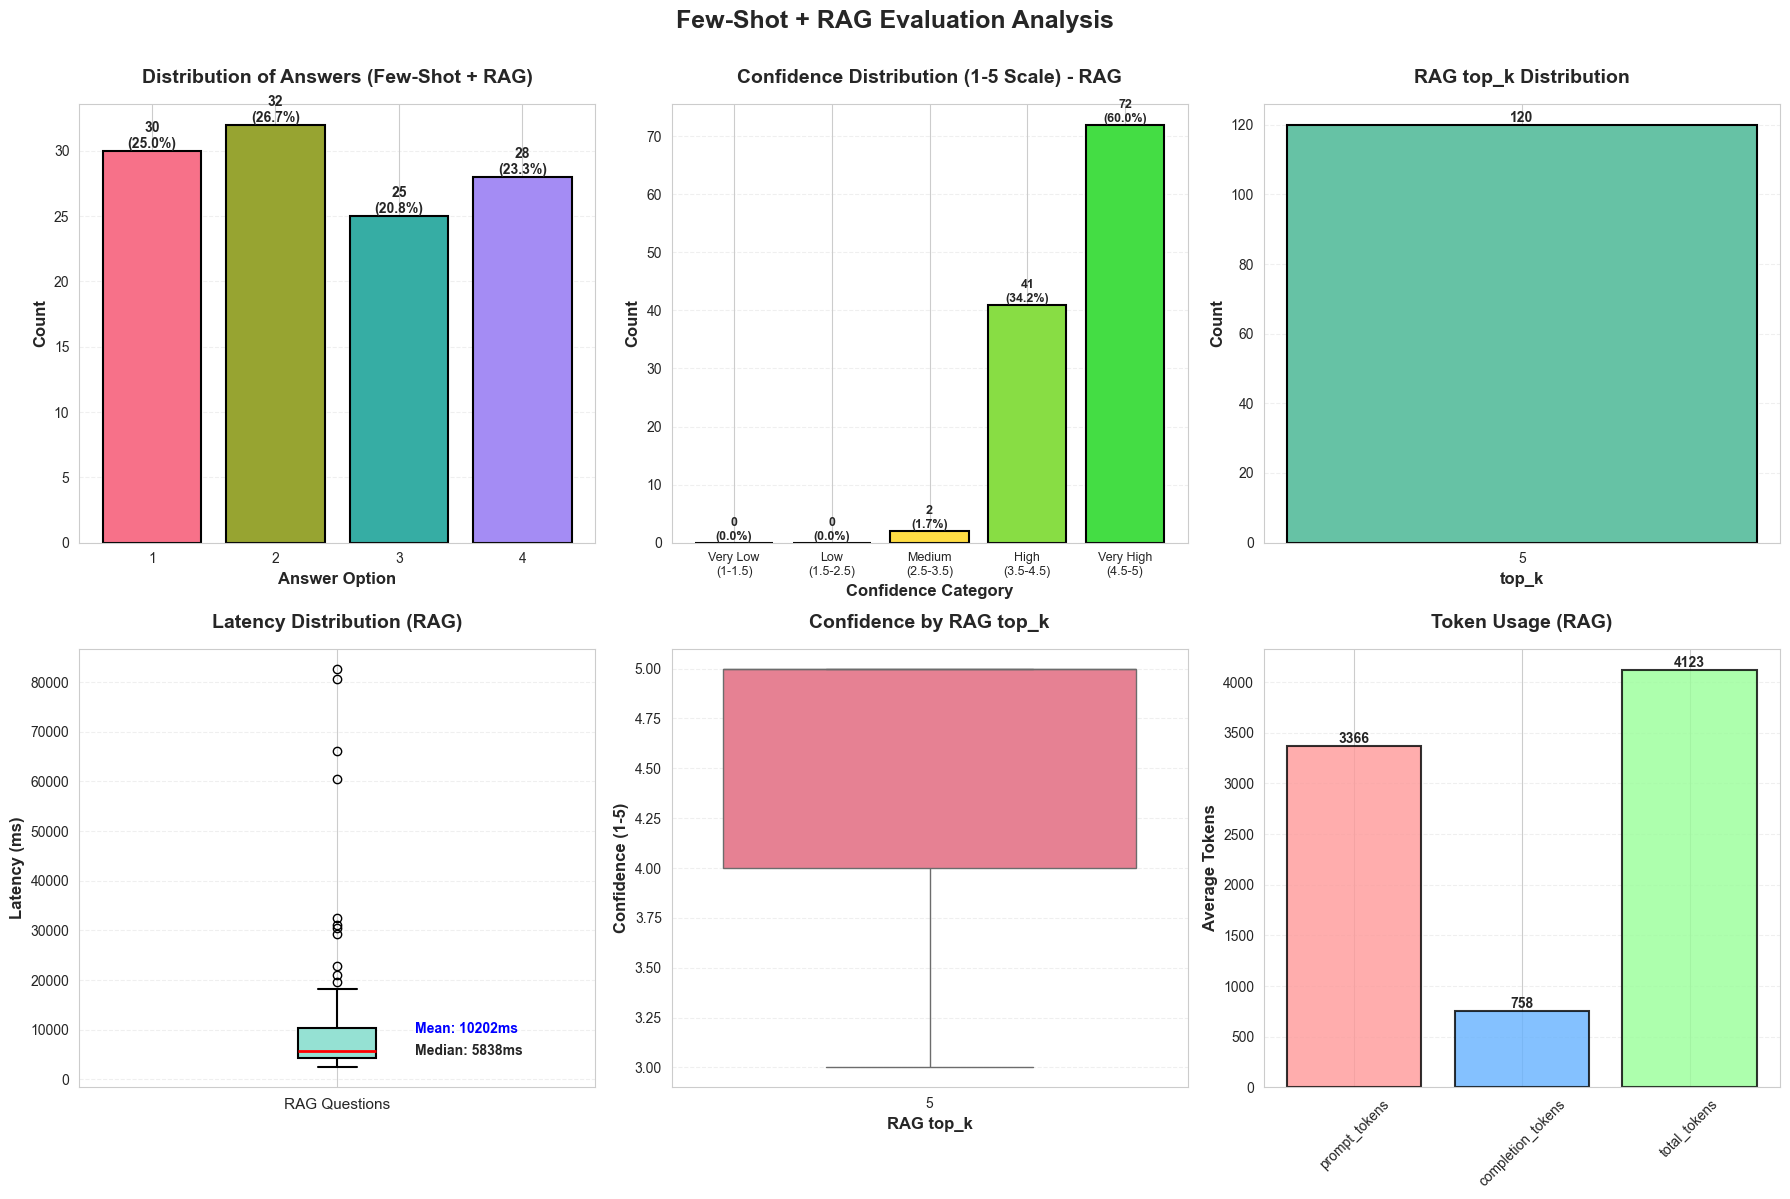

In [16]:
# تنظیمات نمایش فارسی
plt.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")
sns.set_palette("husl")

print("\n" + "="*70)
print("📊 Generating RAG Visualizations")
print("="*70)

# ایجاد فیگور بزرگ با چند subplot
fig = plt.figure(figsize=(18, 12))

# ==================== نمودار ۱: توزیع پاسخ نهایی (RAG) ====================
ax1 = plt.subplot(2, 3, 1)
if 'answer' in results.columns and results['answer'].notna().any():
    answer_counts = results['answer'].dropna().astype(str).value_counts().sort_index()
    colors = sns.color_palette("husl", len(answer_counts))
    bars = ax1.bar(answer_counts.index.astype(str), answer_counts.values, color=colors,
                   edgecolor='black', linewidth=1.5)

    total_n = len(results)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({height/total_n*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_title('Distribution of Answers (Few-Shot + RAG)', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax1.text(0.5, 0.5, 'No answers', ha='center', va='center', fontsize=12)
    ax1.axis('off')

# ==================== نمودار ۲: توزیع Confidence (RAG) ====================
ax2 = plt.subplot(2, 3, 2)
if 'confidence' in results.columns and results['confidence'].notna().any():
    confidence_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.1]
    confidence_labels = ['Very Low\n(1-1.5)', 'Low\n(1.5-2.5)', 'Medium\n(2.5-3.5)', 'High\n(3.5-4.5)', 'Very High\n(4.5-5)']

    conf_cat = pd.cut(
        results['confidence'],
        bins=confidence_bins,
        labels=confidence_labels,
        include_lowest=True,
        right=False
    )
    conf_counts = conf_cat.value_counts().sort_index()

    colors_conf = ['#FF4444', '#FF8844', '#FFDD44', '#88DD44', '#44DD44']
    bars2 = ax2.bar(range(len(conf_counts)), conf_counts.values,
                    color=colors_conf[:len(conf_counts)],
                    edgecolor='black', linewidth=1.5)

    total_n = len(results)
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({height/total_n*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2.set_xticks(range(len(conf_counts)))
    ax2.set_xticklabels(conf_counts.index, fontsize=9)
    ax2.set_title('Confidence Distribution (1-5 Scale) - RAG', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Confidence Category', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax2.text(0.5, 0.5, 'No confidence data', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# ==================== نمودار ۳: RAG top_k Distribution ====================
ax3 = plt.subplot(2, 3, 3)
if 'rag_top_k' in results.columns:
    rag_k_counts = results['rag_top_k'].value_counts().sort_index()
    colors_k = sns.color_palette("Set2", len(rag_k_counts))
    bars3 = ax3.bar(rag_k_counts.index.astype(str), rag_k_counts.values, color=colors_k,
                    edgecolor='black', linewidth=1.5)
    
    total_n = len(results)
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax3.set_title('RAG top_k Distribution', fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('top_k', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax3.text(0.5, 0.5, 'No rag_top_k data', ha='center', va='center', fontsize=12)
    ax3.axis('off')

# ==================== نمودار ۴: Boxplot Latency (RAG) ====================
ax4 = plt.subplot(2, 3, 4)
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_latency = results['latency_ms'].dropna()
    ax4.boxplot(valid_latency, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))

    ax4.set_title('Latency Distribution (RAG)', fontsize=14, fontweight='bold', pad=15)
    ax4.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax4.set_xticklabels(['RAG Questions'], fontsize=11)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

    median_lat = valid_latency.median()
    mean_lat = valid_latency.mean()
    ax4.text(1.15, median_lat, f'Median: {median_lat:.0f}ms', fontsize=10, fontweight='bold', va='center')
    ax4.text(1.15, mean_lat, f'Mean: {mean_lat:.0f}ms', fontsize=10, fontweight='bold', va='center', color='blue')
else:
    ax4.text(0.5, 0.5, 'No latency data', ha='center', va='center', fontsize=12)
    ax4.axis('off')
    
# ==================== نمودار ۵: Confidence vs RAG top_k ====================
ax5 = plt.subplot(2, 3, 5)
if all(col in results.columns for col in ['confidence', 'rag_top_k']):
    valid_data = results.dropna(subset=['confidence', 'rag_top_k'])
    if len(valid_data) > 0:
        sns.boxplot(data=valid_data, x='rag_top_k', y='confidence', ax=ax5, palette='husl')
        ax5.set_title('Confidence by RAG top_k', fontsize=14, fontweight='bold', pad=15)
        ax5.set_xlabel('RAG top_k', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Confidence (1-5)', fontsize=12, fontweight='bold')
        ax5.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax5.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax5.axis('off')
else:
    ax5.text(0.5, 0.5, 'No rag_top_k/confidence data', ha='center', va='center', fontsize=12)
    ax5.axis('off')

# ==================== نمودار ۶: Token Usage Comparison ====================
ax6 = plt.subplot(2, 3, 6)
token_cols = ['prompt_tokens', 'completion_tokens', 'total_tokens']
available_tokens = [col for col in token_cols if col in results.columns]
if len(available_tokens) > 0:
    token_data = results[available_tokens].dropna()
    if len(token_data) > 0:
        token_means = token_data.mean()
        colors_token = ['#FF9999', '#66B2FF', '#99FF99']
        bars6 = ax6.bar(token_means.index, token_means.values, 
                        color=colors_token[:len(token_means)], alpha=0.8,
                        edgecolor='black', linewidth=1.5)
        
        ax6.set_title('Token Usage (RAG)', fontsize=14, fontweight='bold', pad=15)
        ax6.set_ylabel('Average Tokens', fontsize=12, fontweight='bold')
        ax6.tick_params(axis='x', rotation=45)
        ax6.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar in bars6:
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.0f}', ha='center', va='bottom', fontweight='bold')
    else:
        ax6.text(0.5, 0.5, 'No token data', ha='center', va='center', fontsize=12)
        ax6.axis('off')
else:
    ax6.text(0.5, 0.5, 'No token columns', ha='center', va='center', fontsize=12)
    ax6.axis('off')

# ==================== تنظیمات کلی ====================
plt.suptitle('Few-Shot + RAG Evaluation Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

viz_filename = 'visualizations_few_shot_RAG_gpt-oss-120.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Main visualization saved: {viz_filename}")
plt.show()